In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [15]:
import pickle
from src.operations2d import ImageChunk
from src.util import read_video_frames, display_image, get_character_placeholder, read_trimesh
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, find_similar_image_chunk
from src.operations3d import get_intrinsics_for_chunk, apply_mesh_transforms

In [3]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frames = read_video_frames(video_path)
previous_frame = frames[0]
next_frame = frames[1]

In [20]:
# read mesh data from pkl
input_pkl = "output/wooden_cabinet.pkl"
with open(input_pkl, 'rb') as f:
            frames_data = pickle.load(f)
            
class_data = frames_data[0]["classes"][0]
object_class = class_data["class_name"]
mesh_data = class_data["reconstructed_meshes"][0]

unposed_path = mesh_data.get("unposed_mesh_path")
scale = mesh_data.get("scale")
rotation = mesh_data.get("rotation")
translation = mesh_data.get("translation")

chunk_relative_scale = mesh_data.get("chunk_relative_scale")
chunk_relative_rotation = mesh_data.get("chunk_relative_rotation")
chunk_relative_translation = mesh_data.get("chunk_relative_translation")

image_chunk_center = mesh_data.get("image_chunk_center")
image_chunk_size = mesh_data.get("image_chunk_size")

Visualize previous object pose

In [21]:
unadjusted_mesh = read_trimesh(unposed_path)
world_mesh = apply_mesh_transforms(unadjusted_mesh, rotation, translation, scale)

In [22]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(world_mesh), character_placeholder, coordinate_frame])

Detect objects and get image chunk that is close to previous one

In [6]:
previous_image_chunk = ImageChunk.from_image_point(previous_frame, image_chunk_center, image_chunk_size)

In [ ]:
bounding_boxes = get_2d_bounding_boxes(next_frame, object_class)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cpu
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes




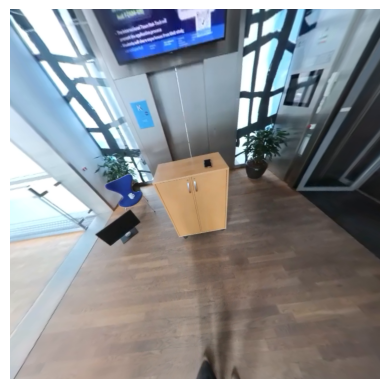

In [10]:
image_chunks = bounding_boxes_to_image_chunks(next_frame, bounding_boxes, orientation="horizontal")
next_image_chunk = find_similar_image_chunk(previous_image_chunk, image_chunks)
display_image(next_image_chunk.image)

In [13]:
# Get camera matrix
K = get_intrinsics_for_chunk(next_image_chunk)
K

array([[215.88321445,   0.        , 350.        ],
       [  0.        , 215.88321445, 350.        ],
       [  0.        ,   0.        ,   1.        ]])

Get object mesh in previous pose relative to camera in OpenCV format

In [23]:
unadjusted_mesh = read_trimesh(unposed_path)
world_mesh = apply_mesh_transforms(unadjusted_mesh, chunk_relative_rotation, chunk_relative_translation, chunk_relative_scale)

In [ ]:
#TODO: convert to opencv format
#TODO: perform RAPID step
#TODO: adjust by chunk rotation
#TODO: write back local and global rotation and set next iamge chunk